# Modelando la Economía a partir de un gas ideal

La econofísica propone que, así como las moléculas en un gas intercambian energía mediante colisiones, los agentes económicos intercambian dinero a través de transacciones. En un sistema cerrado, la cantidad total de dinero se conserva localmente en cada transacción, de la misma forma que se conserva la energía en la física.

Para entender estos modelos, primero debemos definir matemáticamente los dos ensambles de la mecánica estadística que utilizaremos como analogía.

### 1. El Ensamble Canónico (Sistemas Cerrados)
Describe un sistema físico cerrado que está en equilibrio térmico con un baño de calor (Temperatura cte). El número de partículas y el volumen son fijos, pero el sistema puede intercambiar energía. La probabilidad $P(\epsilon)$ de encontrar el sistema en un estado con energía $\epsilon$ está dada por la distribución de Boltzmann-Gibbs:

$$P(\epsilon) = \frac{1}{Z} e^{-\epsilon/T}$$

**Explicación de las variables:**
* **$\epsilon$**: Es la energía de un estado particular del sistema.
* **$T$**: Es la temperatura del sistema (aquí asumimos que la constante de Boltzmann $k_B = 1$ para simplificar ).
* **$Z$**: Es la **función de partición canónica**. 

La función de partición $Z$ es fundamental. Se define como la suma de los factores de Boltzmann sobre todos los microestados posibles $k$:
$$Z = \sum_k e^{-\epsilon_k/T}$$
Su propósito principal es servir como una constante de normalización: garantiza que la suma de las probabilidades de todos los estados posibles sea exactamente 1 ($\sum P(\epsilon_k) = 1$). En termodinámica, si uno conoce $Z$, puede derivar todas las variables macroscópicas del sistema (como la energía libre, la entropía, etc.).

### 2. El Ensamble Gran Canónico (Sistemas Abiertos / Con Reservorio)
Describe un sistema abierto que puede intercambiar tanto energía como partículas con un reservorio externo. Aquí, el número de partículas $N$ no es fijo. La probabilidad de un estado es:

$$P(\epsilon, N) = \frac{1}{\mathcal{Z}} e^{-(\epsilon - \mu N)/T}$$

**Explicación de las variables:**
* **$N$**: Es el número de partículas en el microestado particular.
* **$\mu$**: Es el potencial químico, que representa el cambio en la energía del sistema al añadir o quitar una partícula.
* **$\mathcal{Z}$**: Es la **gran función de partición**. A diferencia de $Z$, esta función suma sobre todos los estados $k$ y sobre todos los números posibles de partículas $N$:
$$\mathcal{Z} = \sum_N \sum_k e^{-(\epsilon_k - \mu N)/T}$$

En nuestra analogía económica, un banco actuará de manera similar a este reservorio, permitiendo a los agentes tener "dinero negativo" (deuda) y desplazando la condición de contorno de nuestro sistema.

## Modelo de Intercambio de Dinero sin Deuda

Según el modelo de Drăgulescu y Yakovenko (2000), consideremos una economía cerrada donde la deuda no está permitida. Esto significa que el balance de dinero $m_i$ de cualquier agente siempre debe ser mayor o igual a cero ($m_i \ge 0$).

Si dos agentes realizan una transacción por un monto $\Delta m$, la transacción solo se concreta si el pagador tiene suficiente dinero ($m_i \ge \Delta m$). Bajo estas reglas, la distribución estacionaria del dinero converge a la distribución exponencial de Boltzmann-Gibbs:

$$P(m) = c e^{-m/T_m}$$

Donde la "temperatura del dinero" $T_m$ es igual a la cantidad promedio de dinero por agente: $T_m = M / N$. A continuación, replicaremos la simulación exacta del paper, utilizando $N=500$ agentes, un total de dinero $M=5 \cdot 10^5$, y un tiempo de $4 \cdot 10^5$ iteraciones.

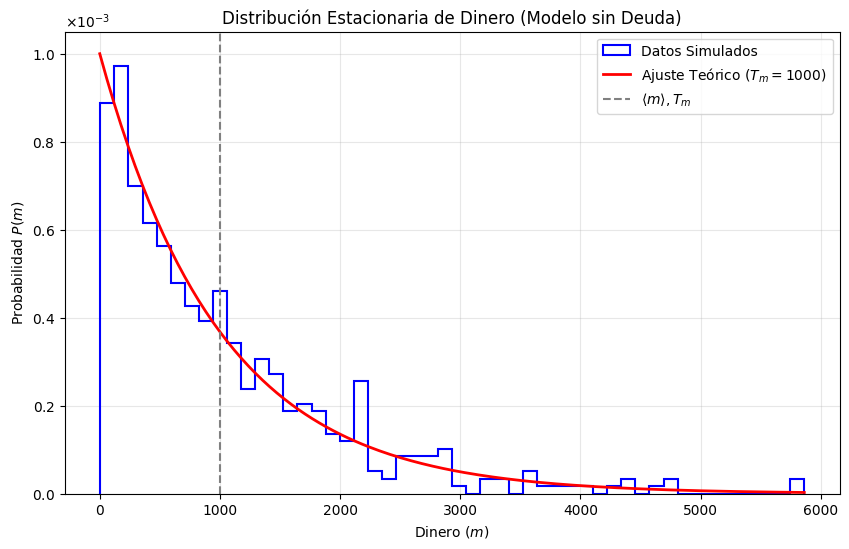

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Parámetros exactos de la simulación de Drăgulescu y Yakovenko (2000)
N = 500              # Número de agentes
M = 500000           # Dinero total en el sistema
T_m = M / N          # Temperatura del dinero (promedio = 1000)
time_steps = 400000  # Iteraciones de tiempo

# Inicializamos todos los agentes con la misma cantidad de dinero (1000)
dinero = np.full(N, T_m)

# En el paper, el delta_m transferido es una fracción aleatoria del promedio de dinero por agente
# delta_m = v * (M/N), donde v es un número aleatorio uniforme entre 0 y 1.
for _ in range(time_steps):
    i, j = np.random.choice(N, 2, replace=False) # Elegimos pagador (i) y receptor (j)
    
    # Monto a transferir
    v = np.random.uniform(0, 1)
    delta_m = v * T_m
    
    # Condición de contorno: el pagador no puede quedar con saldo negativo
    if dinero[i] >= delta_m:
        dinero[i] -= delta_m
        dinero[j] += delta_m

plt.figure(figsize=(10, 6))
ax = plt.gca()

plt.hist(dinero, bins=50, density=True, histtype='step', color='blue', lw=1.5, label='Datos Simulados')

# Curva teórica de Boltzmann-Gibbs
m_vals = np.linspace(0, max(dinero), 200)
p_m_teo = (1/T_m) * np.exp(-m_vals / T_m)
plt.plot(m_vals, p_m_teo, 'r-', lw=2, label=f'Ajuste Teórico ($T_m = {int(T_m)}$)')

# Configuración del eje Y con notación científica y multiplicador superior
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

plt.title('Distribución Estacionaria de Dinero (Modelo sin Deuda)')
plt.xlabel('Dinero ($m$)')
plt.ylabel('Probabilidad $P(m)$')
plt.axvline(T_m, color='gray', linestyle='--', label=r'$\langle m \rangle, T_m$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Modelo de Intercambio con Deuda Permitida

Desde la perspectiva de los agentes, la deuda puede considerarse como "dinero negativo". Cuando un agente pide prestado a un banco, adquiere efectivo (dinero positivo) y una obligación (dinero negativo), manteniendo su valor neto intacto. 

El paper advierte que si se permite una deuda ilimitada, el sistema se vuelve inestable y la probabilidad nunca alcanza un estado estacionario (se ensancha infinitamente de forma Gaussiana). Para evitar esto, se impone una condición de contorno modificada: la deuda máxima se limita a un valor $m_d$. Es decir, $m_i \ge -m_d$.

Al permitir deuda hasta $m_d$, la temperatura efectiva del sistema aumenta, ya que se incrementa el dinero "disponible" por agente. La nueva temperatura es $T_d = T_m + m_d$. 

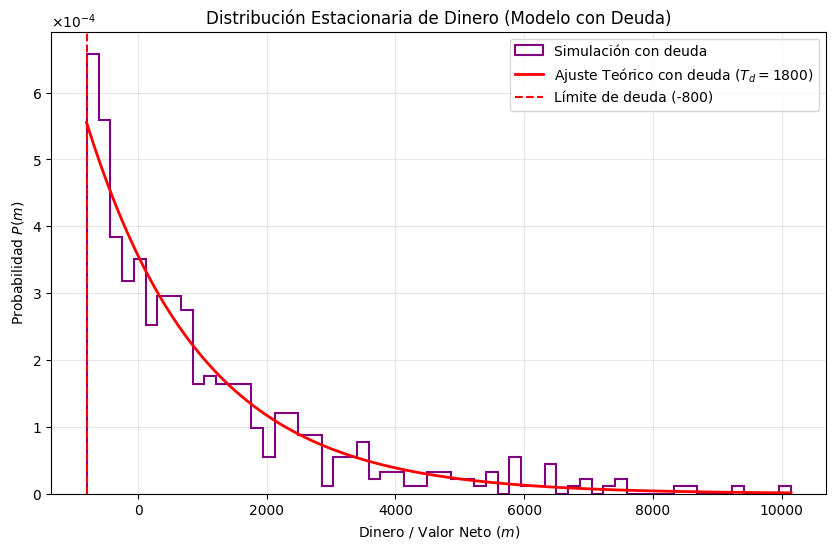

In [7]:
# Parámetros para el modelo de deuda
m_d = 800            # Deuda máxima permitida por agente
T_d = T_m + m_d      # Nueva temperatura efectiva del dinero (1000 + 800 = 1800)

# Reiniciamos las cuentas de los agentes (balance neto inicial = 1000)
dinero_neto = np.full(N, T_m)

for _ in range(time_steps):
    i, j = np.random.choice(N, 2, replace=False)
    
    v = np.random.uniform(0, 1)
    delta_m = v * T_m
    
    if dinero_neto[i] - delta_m >= -m_d:
        dinero_neto[i] -= delta_m
        dinero_neto[j] += delta_m

plt.figure(figsize=(10, 6))
ax = plt.gca()

plt.hist(dinero_neto, bins=60, density=True, histtype='step', color='purple', lw=1.5, label='Simulación con deuda')

m_vals_d = np.linspace(-m_d, max(dinero_neto), 200)
p_m_teo_d = (1/T_d) * np.exp(-(m_vals_d + m_d) / T_d)
plt.plot(m_vals_d, p_m_teo_d, 'r-', lw=2, label=f'Ajuste Teórico con deuda ($T_d = {int(T_d)}$)')

plt.axvline(-m_d, color='red', linestyle='--', label=f'Límite de deuda (-{m_d})')

# Configuración del eje Y con notación científica y multiplicador superior
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

plt.title('Distribución Estacionaria de Dinero (Modelo con Deuda)')
plt.xlabel('Dinero / Valor Neto ($m$)')
plt.ylabel('Probabilidad $P(m)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Comparación: El Impacto de la Deuda en la Desigualdad

Para visualizar claramente el efecto de la deuda en la economía, vamos a superponer ambos modelos. 
Matemáticamente, lo que estamos haciendo es cambiar la condición de contorno del estado fundamental de $m=0$ a $m=-m_d$. 

Como calculamos teóricamente:
* **Temperatura sin deuda ($T_m$):** Es simplemente el dinero total dividido por el número de agentes. Con $M=5 \cdot 10^5$ y $N=500$, tenemos $T_m = 1000$.
* **Temperatura con deuda ($T_d$):** Al permitir que los agentes se endeuden hasta $m_d = 800$, la cantidad de dinero *efectivamente disponible* para gastar aumenta. La nueva temperatura teórica es $T_d = T_m + m_d = 1000 + 800 = 1800$.

Al aumentar la temperatura, la curva exponencial decae más lentamente, lo que en términos económicos significa que **aumenta la desigualdad**: hay más agentes con balances muy negativos (endeudados) y, por conservación del dinero, permite que otros agentes acumulen mucha más riqueza en la cola positiva.

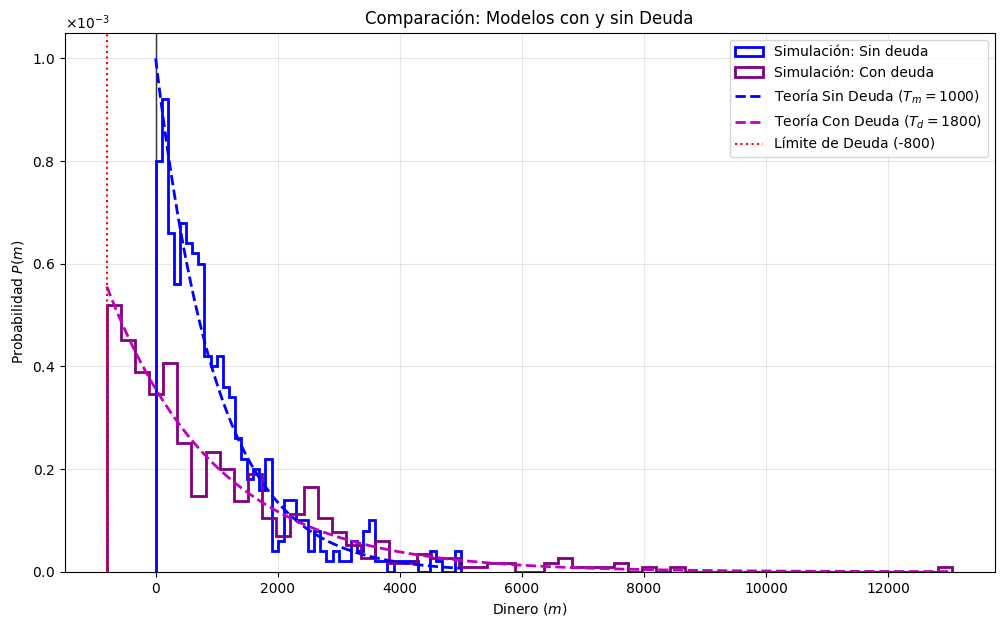

In [6]:
# Parámetros base
N = 500
M = 500000
T_m = M / N          # T_m = 1000 [cite: 244, 341]
m_d = 800            # Límite de deuda [cite: 371, 374]
T_d = T_m + m_d      # T_d = 1800 
time_steps = 400000  # [cite: 246, 341]

dinero_sin_deuda = np.full(N, T_m)
dinero_con_deuda = np.full(N, T_m)

for _ in range(time_steps):
    i, j = np.random.choice(N, 2, replace=False)
    v1, v2 = np.random.uniform(0, 1, 2)
    
    # Transacción modelo sin deuda
    delta_m1 = v1 * T_m
    if dinero_sin_deuda[i] >= delta_m1:
        dinero_sin_deuda[i] -= delta_m1
        dinero_sin_deuda[j] += delta_m1
        
    # Transacción modelo con deuda
    delta_m2 = v2 * T_m
    if dinero_con_deuda[i] - delta_m2 >= -m_d:
        dinero_con_deuda[i] -= delta_m2
        dinero_con_deuda[j] += delta_m2

plt.figure(figsize=(12, 7))
ax = plt.gca()

plt.hist(dinero_sin_deuda, bins=50, density=True, histtype='step', color='blue', lw=2, label='Simulación: Sin deuda')
plt.hist(dinero_con_deuda, bins=60, density=True, histtype='step', color='purple', lw=2, label='Simulación: Con deuda')

# Curvas teóricas
m_vals_sin = np.linspace(0, max(dinero_sin_deuda), 200)
p_m_sin = (1/T_m) * np.exp(-m_vals_sin / T_m)
plt.plot(m_vals_sin, p_m_sin, 'b--', lw=2, label=f'Teoría Sin Deuda ($T_m={int(T_m)}$)')

m_vals_con = np.linspace(-m_d, max(dinero_con_deuda), 200)
p_m_con = (1/T_d) * np.exp(-(m_vals_con + m_d) / T_d)
plt.plot(m_vals_con, p_m_con, 'm--', lw=2, label=f'Teoría Con Deuda ($T_d={int(T_d)}$)')

plt.axvline(0, color='black', lw=1, zorder=0)
plt.axvline(-m_d, color='red', linestyle=':', label='Límite de Deuda (-800)')

# Configuración del eje Y con notación científica y multiplicador superior
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

plt.title('Comparación: Modelos con y sin Deuda')
plt.xlabel('Dinero ($m$)')
plt.ylabel('Probabilidad $P(m)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Rompiendo la Simetría: El Modelo con Propensión al Ahorro

Los modelos anteriores son **aditivos**: la cantidad transferida depende de una constante o del promedio global. Estos modelos respetan la *simetría de inversión temporal* (la probabilidad de que $A$ le pague a $B$ es igual a la de que $B$ le pague a $A$), lo que invariablemente lleva a una distribución exponencial de Boltzmann-Gibbs.

Pero, ¿qué pasa si los agentes deciden **ahorrar** una fracción de su propio dinero antes de comerciar? 

Chakraborti y Chakrabarti (2000) introdujeron un modelo donde cada agente guarda una fracción $\lambda$ (propensión al ahorro) de su dinero y solo arriesga el resto $(1-\lambda)m_i$ en las transacciones. El intercambio se vuelve **multiplicativo**, porque el monto transferido depende de la riqueza actual del individuo.

La regla de intercambio entre dos agentes $i$ y $j$ se convierte en:
$$m_i' = \lambda m_i + \epsilon (1-\lambda)(m_i + m_j)$$
$$m_j' = \lambda m_j + (1-\epsilon)(1-\lambda)(m_i + m_j)$$
donde $\epsilon$ es un número aleatorio entre 0 y 1.

Este pequeño cambio rompe la simetría temporal. La nueva distribución estacionaria deja de ser exponencial y se convierte en una **Distribución Gamma**:
$$P(m) = c \, m^\beta e^{-m/T}$$

En esta distribución, hay menos personas con riqueza exactamente cero (porque siempre ahorran algo), lo que desplaza el pico de la curva hacia la derecha.

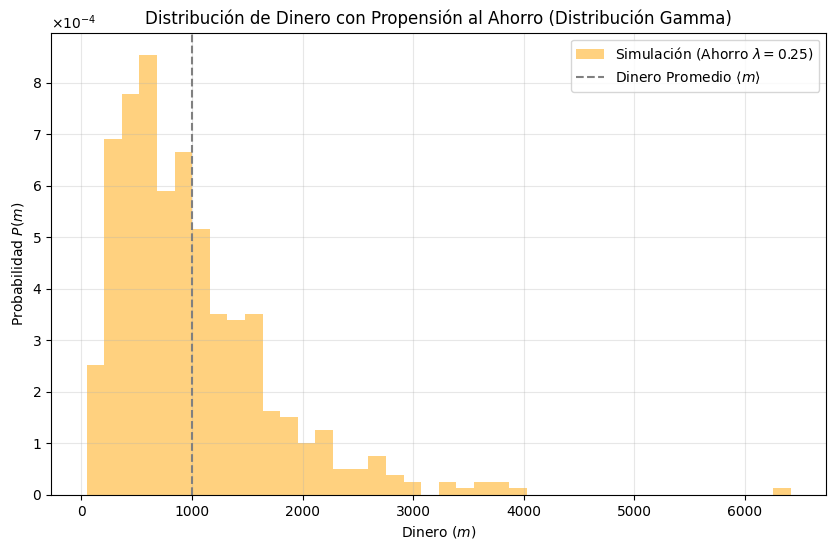

In [5]:
N = 500
M = 500000
T_m = M / N
time_steps = 1000000 
lambd = 0.25 

dinero_ahorro = np.full(N, T_m)

for _ in range(time_steps):
    i, j = np.random.choice(N, 2, replace=False)
    eps = np.random.uniform(0, 1)
    dinero_en_juego = (1 - lambd) * (dinero_ahorro[i] + dinero_ahorro[j])
    m_i_new = lambd * dinero_ahorro[i] + eps * dinero_en_juego
    m_j_new = lambd * dinero_ahorro[j] + (1 - eps) * dinero_en_juego
    dinero_ahorro[i] = m_i_new
    dinero_ahorro[j] = m_j_new

plt.figure(figsize=(10, 6))
ax = plt.gca()

plt.hist(dinero_ahorro, bins=40, density=True, histtype='stepfilled', alpha=0.5, color='orange', label=rf'Simulación (Ahorro $\lambda={lambd}$)')

plt.title('Distribución de Dinero con Propensión al Ahorro (Distribución Gamma)')
plt.xlabel('Dinero ($m$)')
plt.ylabel('Probabilidad $P(m)$')
plt.axvline(T_m, color='gray', linestyle='--', label=r'Dinero Promedio $\langle m \rangle$')

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Análisis de los Resultados con Ahorro

A diferencia de los gráficos anteriores (donde la probabilidad máxima estaba en $m=0$ o en el límite de deuda $-m_d$), la curva obtenida con la propensión al ahorro adopta la forma de una **Distribución Gamma**. 

Físicamente, esto ocurre porque rompimos la simetría de inversión temporal. Económicamente, los resultados muestran que:
1. **La pobreza extrema disminuye:** Como los agentes siempre guardan una fracción de su riqueza antes de comerciar, es matemáticamente imposible que lleguen a un balance de $0$ tras una transacción (a menos que ya tuvieran $0$). Esto elimina el pico en el origen.
2. **Surge una "clase media":** El pico de la distribución se desplaza hacia la derecha. La mayoría de la población ahora se agrupa alrededor de un valor intermedio de riqueza, generando una sociedad más equitativa en comparación con el modelo exponencial puro.

## 5. Ergodicidad en la Econofísica

El hecho de que podamos usar la mecánica estadística para predecir la distribución del dinero en una sociedad se apoya en un pilar fundamental de la física: la **Hipótesis Ergódica**.

### ¿Qué es la Ergodicidad?
En física estadística, un sistema es *ergódico* si, dado el tiempo suficiente, explora todos los microestados posibles (todas las configuraciones de energía o dinero) respetando las leyes de conservación. Matemáticamente, la ergodicidad establece que **el promedio en el tiempo de una sola partícula es igual al promedio del ensamble (todas las partículas) en un instante dado**.

$$\lim_{T \to \infty} \frac{1}{T} \int_0^T m_i(t) dt = \frac{1}{N} \sum_{j=1}^N m_j(t_{fijo})$$

### Su Significado en la Economía
En nuestros primeros modelos (sin ahorro), el sistema económico simulado es ergódico. Esto tiene implicaciones filosóficas y sociales muy profundas:
1. **Movilidad Social Perfecta:** Si se sigue a un solo agente a lo largo de mucho tiempo, su balance de dinero fluctuará y eventualmente pasará por todos los niveles de riqueza posibles (desde la quiebra absoluta $m=0$ hasta ser inmensamente rico), con una frecuencia dictada por la curva exponencial de Boltzmann-Gibbs.
2. **La Desigualdad es Estructural, no Individual:** Si se toma una "fotografía" de toda la sociedad en un instante dado (promedio de ensamble), se verá la curva exponencial. La mayoría es pobre y unos pocos son ricos. Sin embargo, debido a la ergodicidad, *quién* es el rico y *quién* es el pobre cambia constantemente. 

Cuando introducimos reglas como el modelo de propensión al ahorro con tasas aleatorias, o cuando la economía real presenta "ventajas acumulativas" (como el retorno de inversión sobre el capital en los mercados financieros que generan colas de Pareto), **el sistema puede perder su ergodicidad**. En sistemas no ergódicos, los individuos que se vuelven ricos tienden a quedarse ricos, rompiendo la movilidad social perfecta que asume el gas ideal estadístico.

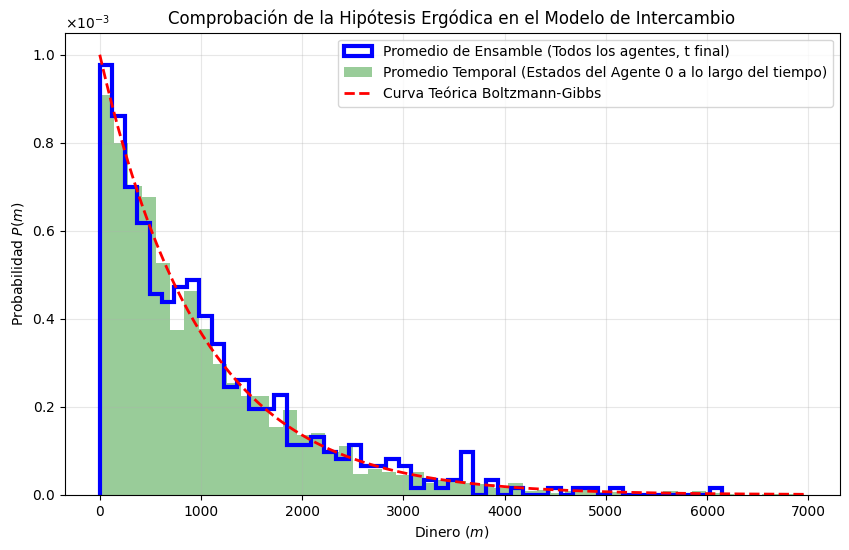

In [ ]:
N = 500
M = 500000
T_m = M / N
time_steps_ergodic = 1500000 

dinero_ergodico = np.full(N, T_m)
historia_agente_0 = np.zeros(time_steps_ergodic)

for t in range(time_steps_ergodic):
    i, j = np.random.choice(N, 2, replace=False)
    v = np.random.uniform(0, 1)
    delta_m = v * T_m
    
    if dinero_ergodico[i] >= delta_m:
        dinero_ergodico[i] -= delta_m
        dinero_ergodico[j] += delta_m
        
    historia_agente_0[t] = dinero_ergodico[0]

plt.figure(figsize=(10, 6))
ax = plt.gca()

plt.hist(dinero_ergodico, bins=50, density=True, histtype='step', color='blue', lw=3, label='Promedio de Ensamble (Todos los agentes, t final)')
plt.hist(historia_agente_0[100000:], bins=50, density=True, alpha=0.4, color='green', label='Promedio Temporal (Estados del Agente 0 a lo largo del tiempo)')

m_vals = np.linspace(0, max(historia_agente_0), 200)
p_m_teo = (1/T_m) * np.exp(-m_vals / T_m)
plt.plot(m_vals, p_m_teo, 'r--', lw=2, label='Curva Teórica Boltzmann-Gibbs')

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

plt.title('Comprobación de la Hipótesis Ergódica en el Modelo de Intercambio')
plt.xlabel('Dinero ($m$)')
plt.ylabel('Probabilidad $P(m)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Análisis de la Simulación Ergódica

El gráfico que acabamos de generar es la confirmación visual de la **hipótesis ergódica** aplicada a nuestro modelo de intercambio. Observando las tres representaciones, podemos extraer conclusiones económicas y físicas muy profundas:

* **Equivalencia de Promedios:** La distribución histórica de los estados financieros del "Agente 0" (barras verdes) coincide casi perfectamente con la distribución de toda la población en el instante final (línea azul escalonada). [cite_start]Esto demuestra que, en este modelo, el sistema de múltiples cuerpos ocupa todos los estados posibles con la misma probabilidad[cite: 179].
* **Concordancia Teórica:** Ambas simulaciones se ajustan fielmente a la curva teórica de Boltzmann-Gibbs (línea roja discontinua). [cite_start]Al igual que una molécula en un gas, la probabilidad de que un agente individual tenga una cantidad específica de dinero está gobernada por esta misma ley exponencial[cite: 180].
* **Movilidad Social Perfecta:** Económicamente, este modelo cerrado representa una sociedad con movilidad social absoluta. La desigualdad existe de forma estructural (siempre hay una gran base de agentes con poco dinero y una minoría con mucho), pero no hay "clases" estáticas. A lo largo del tiempo, un mismo individuo transitará por la pobreza y, eventualmente, experimentará picos de gran riqueza. La desigualdad es del sistema, no una condición permanente del individuo.

**Una advertencia sobre la realidad:**
Aunque este modelo es elegante y útil para entender las transacciones cotidianas de consumo, la economía real no siempre es ergódica. Mecanismos como el interés compuesto, la rentabilidad del capital o las ventajas acumulativas rompen esta simetría temporal. En la realidad, quienes acumulan gran riqueza tienden a mantenerla, lo que da lugar a distribuciones con "colas pesadas" (leyes de Pareto) en lugar de curvas puramente exponenciales.